# XGBOOST

In [1]:
#path config set
import sys
from pathlib import Path

project_root = Path.cwd().parent
for folder in ["functions", "other"]:
    p = str(project_root / folder)
    if p not in sys.path:
        sys.path.append(p)

In [2]:
# import potrebnych kniznic a konfiguracia notebooku
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

    #import importlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

import shap

from cred import DATA_PATH_CRED
from functions_xgboost import make_features, rolling_forecast_xgboost, trace_path_for_observation, extract_tree_structure, hyperparameters_tuning
from functions_general import forecast_plot

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams.update({
    "figure.figsize": (13, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})


print("Importy uspesne.")


C:\Users\adamv\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Importy uspesne.


In [3]:
# konfiguracia a stiahnutie dat
main_dir = Path(DATA_PATH_CRED)
data_mod = "data_mod.csv"
pp_orig = "data.xlsx"
DATA_PATH_DATA_MOD  = main_dir / data_mod
DATA_PATH_DATA = main_dir / pp_orig
SHEET_NAME_PP = "pp"
SHEET_NAME_EXOG = "exog"
TEST_SIZE = 24
RANDOM_STATE = 24
TARGET_VAR = "pp_sa_ca_jd"

df_raw = pd.read_csv(DATA_PATH_DATA_MOD)
df_raw["datum"] = pd.to_datetime(df_raw["datum"])
df_raw = df_raw.set_index("datum").sort_index()
df_raw = df_raw.asfreq("MS")
df = df_raw.copy()

df_pp = pd.read_excel(DATA_PATH_DATA,SHEET_NAME_PP)
df_pp = df_pp.set_index("datum").sort_index()
df_pp = df_pp.asfreq("MS")


In [4]:
#definovanie features, train/test vzorka
exog_cols = df.drop(columns=[TARGET_VAR,"pp_non_sa","pp_sa_orig","cpi_non_sa", "oil_europe_usd"])
features = make_features(
    data=df,
    target=TARGET_VAR,
    exog_cols=exog_cols,
    target_lags=(1, 2, 3, 6, 12),
    exog_lags=(1,)
)

X = features.drop(columns = [TARGET_VAR, "pp_sa_ca_jd_lag1"])
y = features[TARGET_VAR]

X_train, X_test = X.iloc[:-TEST_SIZE], X.iloc[-TEST_SIZE:]
y_train, y_test = y.iloc[:-TEST_SIZE], y.iloc[-TEST_SIZE:]

print(f"Trenovacia mnozina: {y_train.index.min().date()} az {y_train.index.max().date()} ({len(y_train)} obs.)")
print(f"Testovacia mnozina: {y_test.index.min().date()} az {y_test.index.max().date()} ({len(y_test)} obs.)")


Trenovacia mnozina: 2001-02-01 az 2023-12-01 (275 obs.)
Testovacia mnozina: 2024-01-01 az 2025-12-01 (24 obs.)


In [5]:
grid_search, best_params = hyperparameters_tuning(X_train, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Najlepsie parametre z Random Search: {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0.01, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.005, 'gamma': 1, 'colsample_bytree': 0.7}
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Finalne parametre po Grid Search: {'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.0025, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 200, 'reg_alpha': 0.01, 'reg_lambda': 1, 'subsample': 0.6}


In [6]:
init_train_size = len(y) - TEST_SIZE
xgb_res = rolling_forecast_xgboost(
    X=X,
    y_diff= y,
    level_series=df_pp[TARGET_VAR],
    initial_train_size=init_train_size,
    xgb_params=best_params
)

RMSE (diferencia):      2.4782
RMSE (level, onestep):  2.4782
WMAPE (level):          1.93%
ME (level):             -0.4787
Refity:                 24 / 24


In [7]:
results_xgboost = xgb_res["results"]
results_xgboost.to_parquet("data/xgb_res")
diagnostics = xgb_res["diagnostics"]
fi = diagnostics['feature_importance']
hp = diagnostics['hyperparams']
refit_diag = xgb_res["refit_diagnostics"]
summary_xgb = xgb_res["summary"]
summary_xgb = pd.DataFrame([summary_xgb])
summary_xgb.to_parquet("data/xgb_sum")

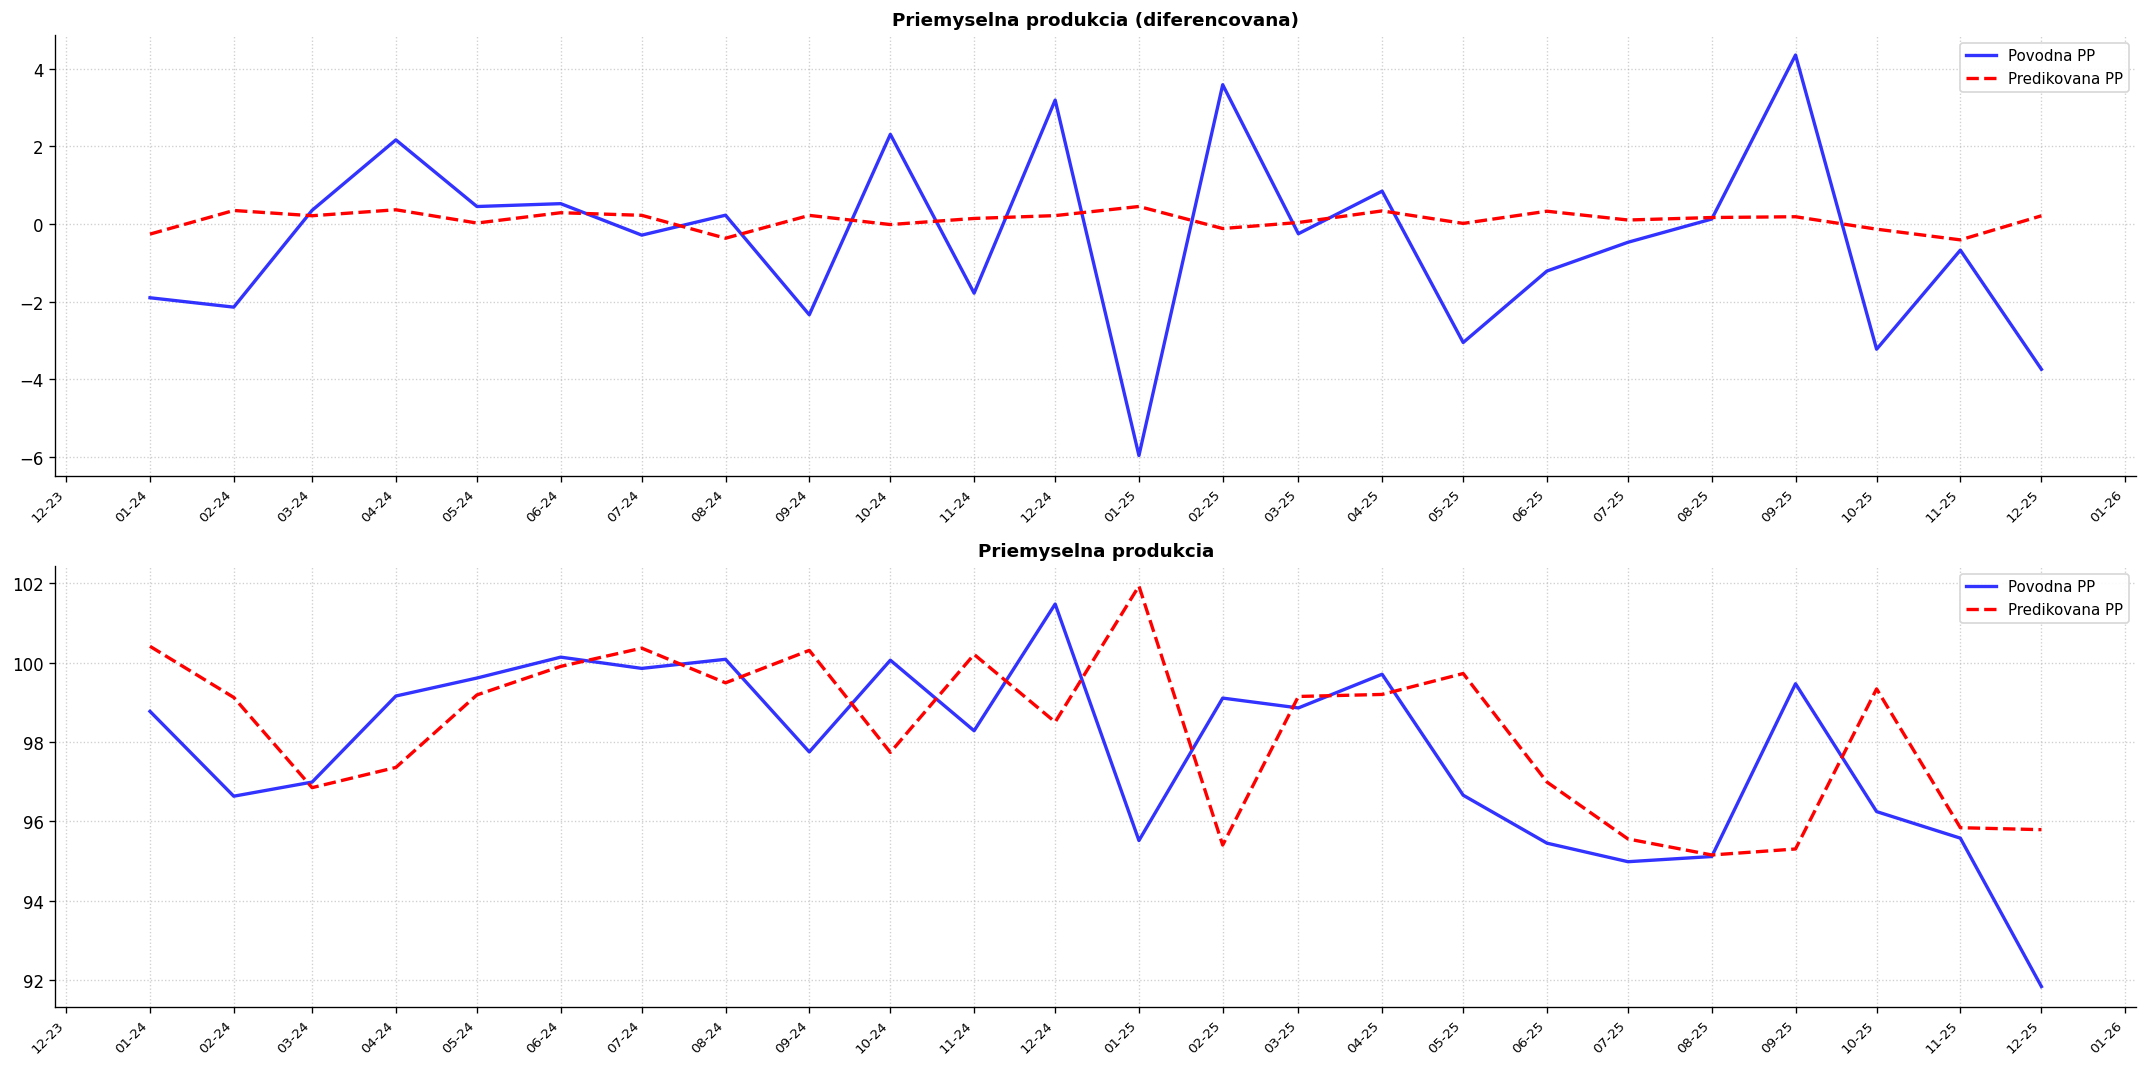

In [8]:
Y_axis = [results_xgboost["actual_diff"], results_xgboost["predicted_diff"], results_xgboost["actual_level"], results_xgboost["predicted_level"]]
X_axis = [results_xgboost.index] * len(Y_axis)
labels = ["Povodna PP", "Predikovana PP"] * len(Y_axis)
titles = ["Priemyselna produkcia (diferencovana)", "Priemyselna produkcia"]
colors = ["#0000FF", "#FF0000"] * len(Y_axis)
linestyles = ["-","--"] * len(Y_axis)
linewidths = [] * len(Y_axis)
alphas = [0.8,1] * len(Y_axis)
fig_size = [18,9]
num_rows = 2
num_cols = 1

_ = forecast_plot(X_axis,Y_axis,titles, labels, colors, linestyles, linewidths, alphas,fig_size, num_rows, num_cols)

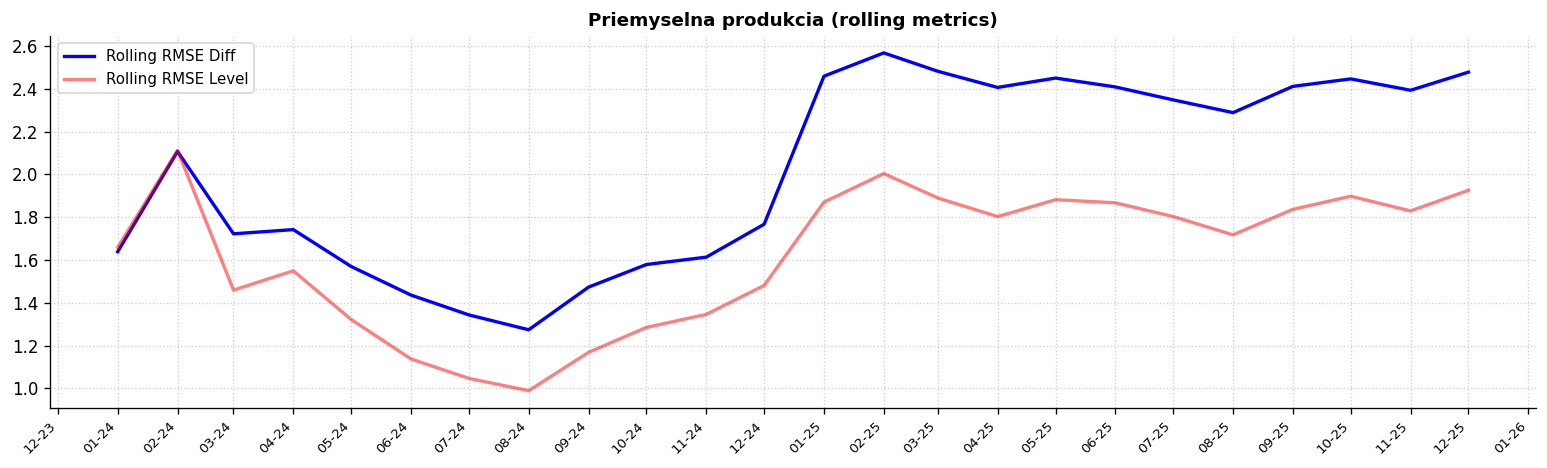

In [9]:
Y_axis = [results_xgboost["rolling_rmse_level"], results_xgboost["rolling_mape_level"]]
X_axis = [results_xgboost.index] * len(Y_axis)
labels = ["Rolling RMSE Diff", "Rolling RMSE Level", "Rolling MAPE Level"] * len(Y_axis)
titles = ["Priemyselna produkcia (rolling metrics)"]
colors = ["#0000FF", "#FF0000", "#008000"] * len(Y_axis)
linestyles = ["-"] * len(Y_axis)
linewidths = [] * len(Y_axis)
alphas = [1, 0.5, 1] * len(Y_axis)
fig_size = [13,4]
num_rows = 1
num_cols = 1
curves_per_plot = 3

_ = forecast_plot(X_axis,Y_axis,titles, labels, colors, linestyles, linewidths, alphas,fig_size, num_rows, num_cols, curves_per_plot)

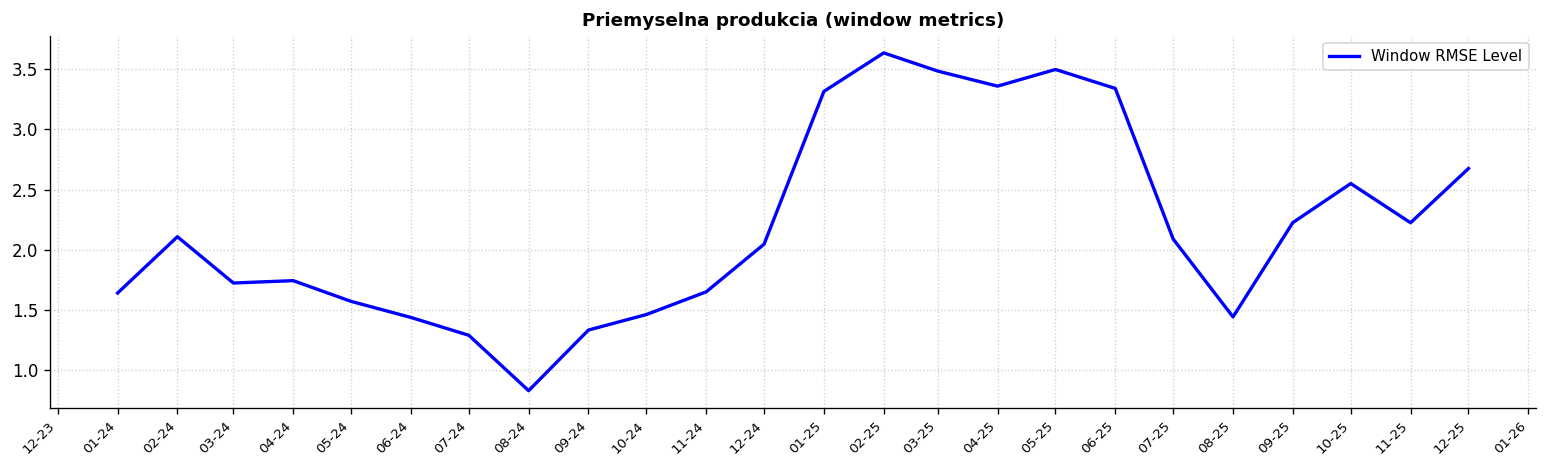

In [10]:
Y_axis = [results_xgboost["window6_rmse_level"]] #results_xgboost["window6_mape_level"], results_xgboost["window6_me_level"]
X_axis = [results_xgboost.index] * len(Y_axis)
labels = ["Window RMSE Level"] * len(Y_axis) #, "Window MAPE Level", "Window ME Level"
titles = ["Priemyselna produkcia (window metrics)"]
colors = ["#0000FF"] * len(Y_axis) #, "#FF0000", "#008000"
linestyles = ["-"] * len(Y_axis)
linewidths = [] * len(Y_axis)
alphas = [1] * len(Y_axis)
fig_size = [13,4]
num_rows = 1
num_cols = 1
curves_per_plot = 3

_ = forecast_plot(X_axis,Y_axis,titles, labels, colors, linestyles, linewidths, alphas,fig_size, num_rows, num_cols, curves_per_plot)

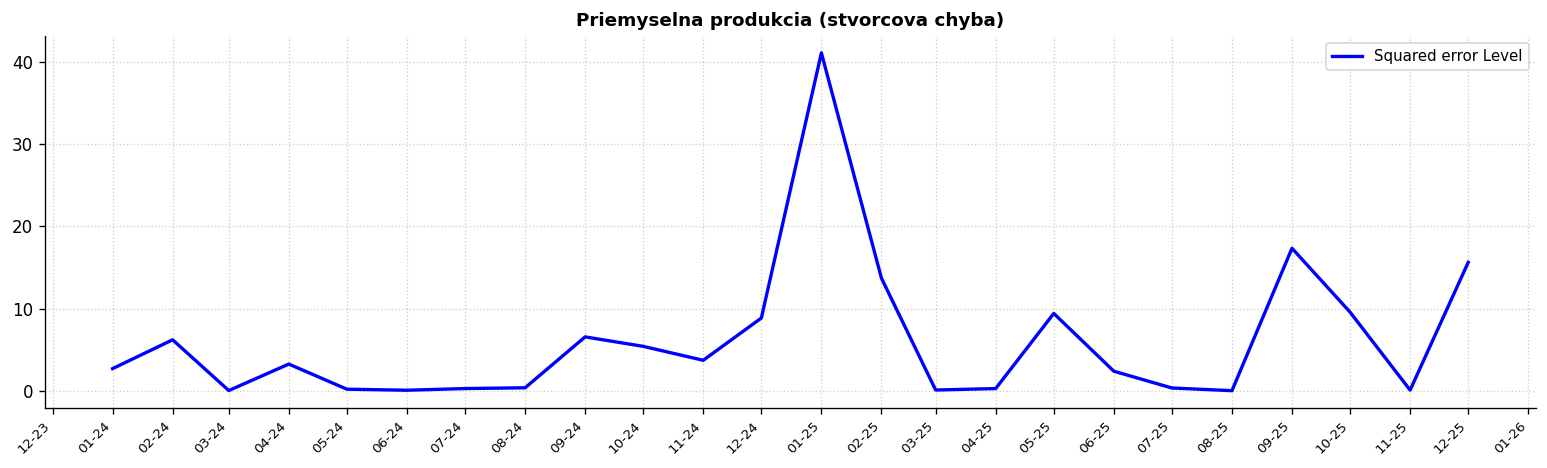

In [11]:
Y_axis = [results_xgboost["sq_error_level"]]
X_axis = [results_xgboost.index] * len(Y_axis)
labels = ["Squared error Level"] * len(Y_axis)
titles = ["Priemyselna produkcia (stvorcova chyba)"]
colors = ["#0000FF"] * len(Y_axis)
linestyles = ["-"] * len(Y_axis)
linewidths = [] * len(Y_axis)
alphas = [1] * len(Y_axis)
fig_size = [13,4]
num_rows = 1
num_cols = 1
curves_per_plot = 3

_ = forecast_plot(X_axis,Y_axis,titles, labels, colors, linestyles, linewidths, alphas,fig_size, num_rows, num_cols, curves_per_plot)

In [12]:
print(xgb_res.keys())

dict_keys(['results', 'models_by_step', 'refit_diagnostics', 'step_diagnostics', 'misaligned_dates', 'summary', 'diagnostics'])


In [13]:
#shap
models_by_step = xgb_res["models_by_step"]
last_date = max(models_by_step.keys())
xgb_model = models_by_step[last_date]

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
shap_summary = pd.DataFrame(shap_values, columns = X_test.columns, index = X_test.index)
mean_abs_shap = np.abs(shap_summary).mean().sort_values(ascending=False)
mean_abs_shap

expected_industry_production_lag1     0.082186
industry_confidence_sa_lag1           0.050760
pp_sa_ca_jd_lag6                      0.031754
vklady_nefinancne_podniky_lag1        0.028967
economic_sentiment_lag1               0.026826
trzby_priemysel_sa_lag1               0.021641
infl_cpi_lag1                         0.020423
ipcv_priemysel_lag1                   0.019728
oil_europe_eur_lag1                   0.018616
pp_sa_ca_jd_lag2                      0.017848
current_total_demand_sa_lag1          0.011576
expected_employment_lag1              0.010441
cdd_lag1                              0.010028
kurz_usd_eur_lag1                     0.009495
pp_sa_ca_jd_lag12                     0.009188
expected_product_prices_lag1          0.007700
sh_prices_non_sa_lag1                 0.007082
fin_stock_lag1                        0.006479
cpi_sa_lag1                           0.005132
inflation_lag1                        0.005047
pp_sa_ca_jd_lag3                      0.004765
unem_prod_lag

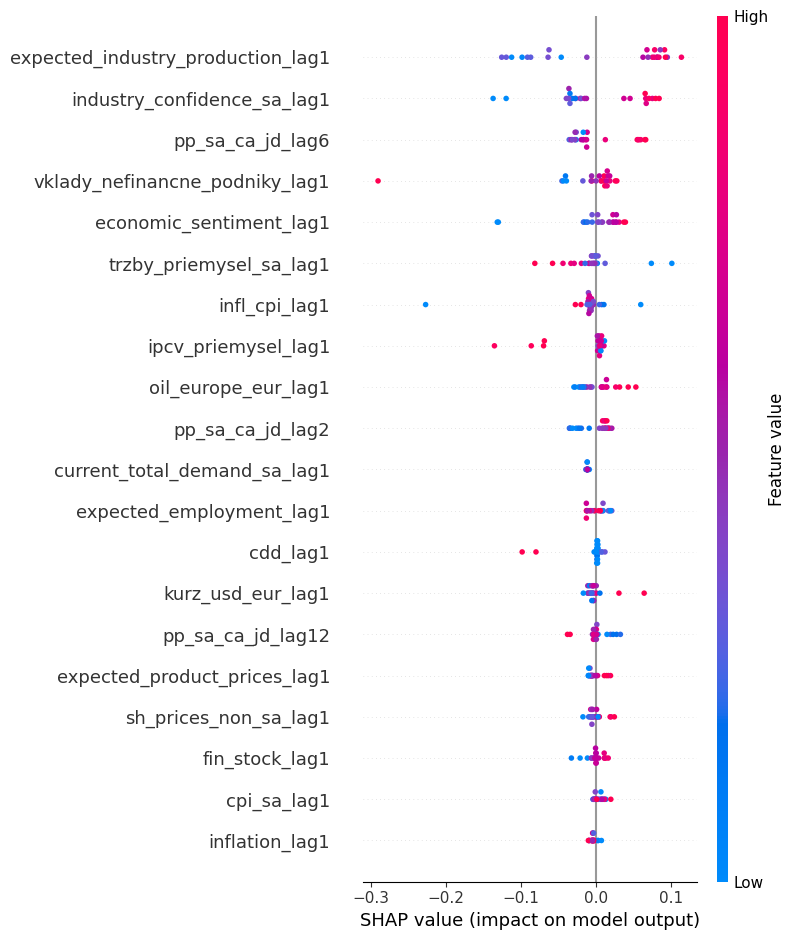

In [14]:
#graf ku shapu
shap.summary_plot(shap_values, X_test)

In [15]:
shap_rows = []

for forecast_date, xgb_model in models_by_step.items():

    X_one = X_test.loc[[forecast_date]].copy()

    explainer = shap.TreeExplainer(xgb_model)
    shap_one = explainer(X_one)

    for feature, value, contribution in zip(X_one.columns, X_one.iloc[0].values, shap_one.values[0]):
        shap_rows.append(
            {
                "forecast_date": forecast_date,
                "feature": feature,
                "feature_value": value,
                "shap_value": contribution,
                "abs_shap_value": abs(contribution),
            }
        )

shap_long = pd.DataFrame(shap_rows)
shap_long


,forecast_date,feature,feature_value,shap_value,abs_shap_value
0,2024-01-01,pp_sa_ca_jd_lag2,-2.366972,-0.031603,0.031603
1,2024-01-01,pp_sa_ca_jd_lag3,2.416140,0.022849,0.022849
2,2024-01-01,pp_sa_ca_jd_lag6,-5.675175,-0.024695,0.024695
3,2024-01-01,pp_sa_ca_jd_lag12,8.032883,-0.013560,0.013560
4,2024-01-01,cpi_sa_lag1,0.816485,0.016589,0.016589
...,...,...,...,...,...
763,2025-12-01,oil_europe_eur_lag1,-0.304100,-0.006457,0.006457
764,2025-12-01,crisis_dummy_lag1,0.000000,0.000000,0.000000
765,2025-12-01,month,12.000000,0.001174,0.001174
766,2025-12-01,quarter,4.000000,-0.000454,0.000454


In [16]:
shap_global = (
    shap_long
    .groupby("feature", as_index= False)
    .agg(
        mean_abs_shap = ("abs_shap_value", "mean"),
        mean_shap = ("shap_value", "mean"),
        median_abs_shap=("abs_shap_value", "median"),
    )
    .sort_values("mean_abs_shap", ascending=False)
)

print(shap_global.head(15).to_string(index=False))

                          feature  mean_abs_shap  mean_shap  median_abs_shap
expected_industry_production_lag1       0.088993   0.011831         0.091512
      industry_confidence_sa_lag1       0.055469   0.004144         0.042323
   vklady_nefinancne_podniky_lag1       0.044661  -0.011437         0.023400
                 pp_sa_ca_jd_lag6       0.035060   0.000355         0.026483
          trzby_priemysel_sa_lag1       0.029511   0.008529         0.005628
          economic_sentiment_lag1       0.028689   0.000979         0.020000
              oil_europe_eur_lag1       0.023031  -0.000096         0.020603
                         cdd_lag1       0.018936  -0.011908         0.002796
                 pp_sa_ca_jd_lag2       0.015855  -0.002483         0.015310
                    infl_cpi_lag1       0.015311  -0.005611         0.012569
              ipcv_priemysel_lag1       0.013202  -0.002063         0.006583
                   fin_stock_lag1       0.012806   0.002431         0.007400

In [17]:
trees_df = extract_tree_structure(xgb_model)

In [18]:
# iba listove uzly (vahy) jedneho konkretneho stromu
tree_0_leaves = trees_df[(trees_df["Tree"] == 0) & (trees_df["Feature"] == "Leaf")]
print(tree_0_leaves[["Tree", "Node", "Gain", "Cover"]])

    Tree  Node      Gain  Cover
1      0     1 -0.028935    1.0
3      0     3  0.021433    2.0
7      0     7 -0.016472    3.0
8      0     8 -0.003494   11.0
9      0     9 -0.000126   99.0
10     0    10  0.003642   49.0


In [19]:
#najcastejsie pouzivane premenne na delenie
split_counts = (
    trees_df[trees_df["Feature"] != "Leaf"]
    .groupby("Feature")
    .size()
    .sort_values(ascending=False)
)
print(split_counts)

Feature
pp_sa_ca_jd_lag2                      186
trzby_priemysel_sa_lag1                94
expected_industry_production_lag1      85
oil_europe_eur_lag1                    83
export_celkovy_sa_lag1                 82
vklady_nefinancne_podniky_lag1         76
infl_cpi_lag1                          70
pp_sa_ca_jd_lag6                       70
industry_confidence_sa_lag1            66
pp_sa_ca_jd_lag12                      66
pp_sa_ca_jd_lag3                       63
current_total_demand_sa_lag1           53
economic_sentiment_lag1                45
cpi_sa_lag1                            42
ipcv_priemysel_lag1                    41
kurz_usd_eur_lag1                      30
sadzba_3m_euribor_lag1                 26
sh_prices_non_sa_lag1                  25
hdd_lag1                               24
uvery_celkom_lag1                      23
foreign_demand_sa_lag1                 22
fin_stock_lag1                         22
cdd_lag1                               22
inflation_lag1            

In [20]:
#priemerny Gain pri deleni podla premennej
avg_gain_by_feature = (
    trees_df[trees_df["Feature"] != "Leaf"]
    .groupby("Feature")["Gain"]
    .mean()
    .sort_values(ascending=False)
)
print(avg_gain_by_feature)

Feature
current_total_demand_sa_lag1          175.014681
oil_europe_eur_lag1                   161.105594
export_celkovy_sa_lag1                159.391404
foreign_demand_sa_lag1                 141.77671
expected_industry_production_lag1      127.33532
trzby_priemysel_sa_lag1               124.137855
industry_confidence_sa_lag1           112.242856
economic_sentiment_lag1                97.212572
vklady_nefinancne_podniky_lag1         87.297834
pp_sa_ca_jd_lag2                       84.847613
infl_cpi_lag1                          78.049627
fin_stock_lag1                         77.411166
cdd_lag1                               76.736595
month                                  72.785326
cpi_sa_lag1                            72.230301
finished_goods_inventories_sa_lag1     70.888369
kurz_usd_eur_lag1                      64.975904
unem_prod_lag1                         62.509546
sh_prices_non_sa_lag1                  61.336213
ipcv_priemysel_lag1                    61.017593
trend       

In [21]:
#kompletna struktura jedneho konkretneho stromu
last_tree = trees_df.iloc[-1, 0]
tree_last_full = trace_path_for_observation(trees_df, tree_index=last_tree)
print(tree_last_full)

      Node                            Feature      Split    Yes      No  \
3029     0                oil_europe_eur_lag1 -13.923057  199-1   199-2   
3030     1                               Leaf       <NA>   <NA>    <NA>   
3031     2       current_total_demand_sa_lag1      -51.0  199-3   199-4   
3032     3                               Leaf       <NA>   <NA>    <NA>   
3033     4  expected_industry_production_lag1       -4.3  199-5   199-6   
3034     5                oil_europe_eur_lag1  -3.264305  199-7   199-8   
3035     6                  kurz_usd_eur_lag1      0.031  199-9  199-10   
3036     7                               Leaf       <NA>   <NA>    <NA>   
3037     8                               Leaf       <NA>   <NA>    <NA>   
3038     9                               Leaf       <NA>   <NA>    <NA>   
3039    10                               Leaf       <NA>   <NA>    <NA>   

           Gain  Cover  
3029  204.82086  190.0  
3030  -0.024898    1.0  
3031  168.12831  189.0  

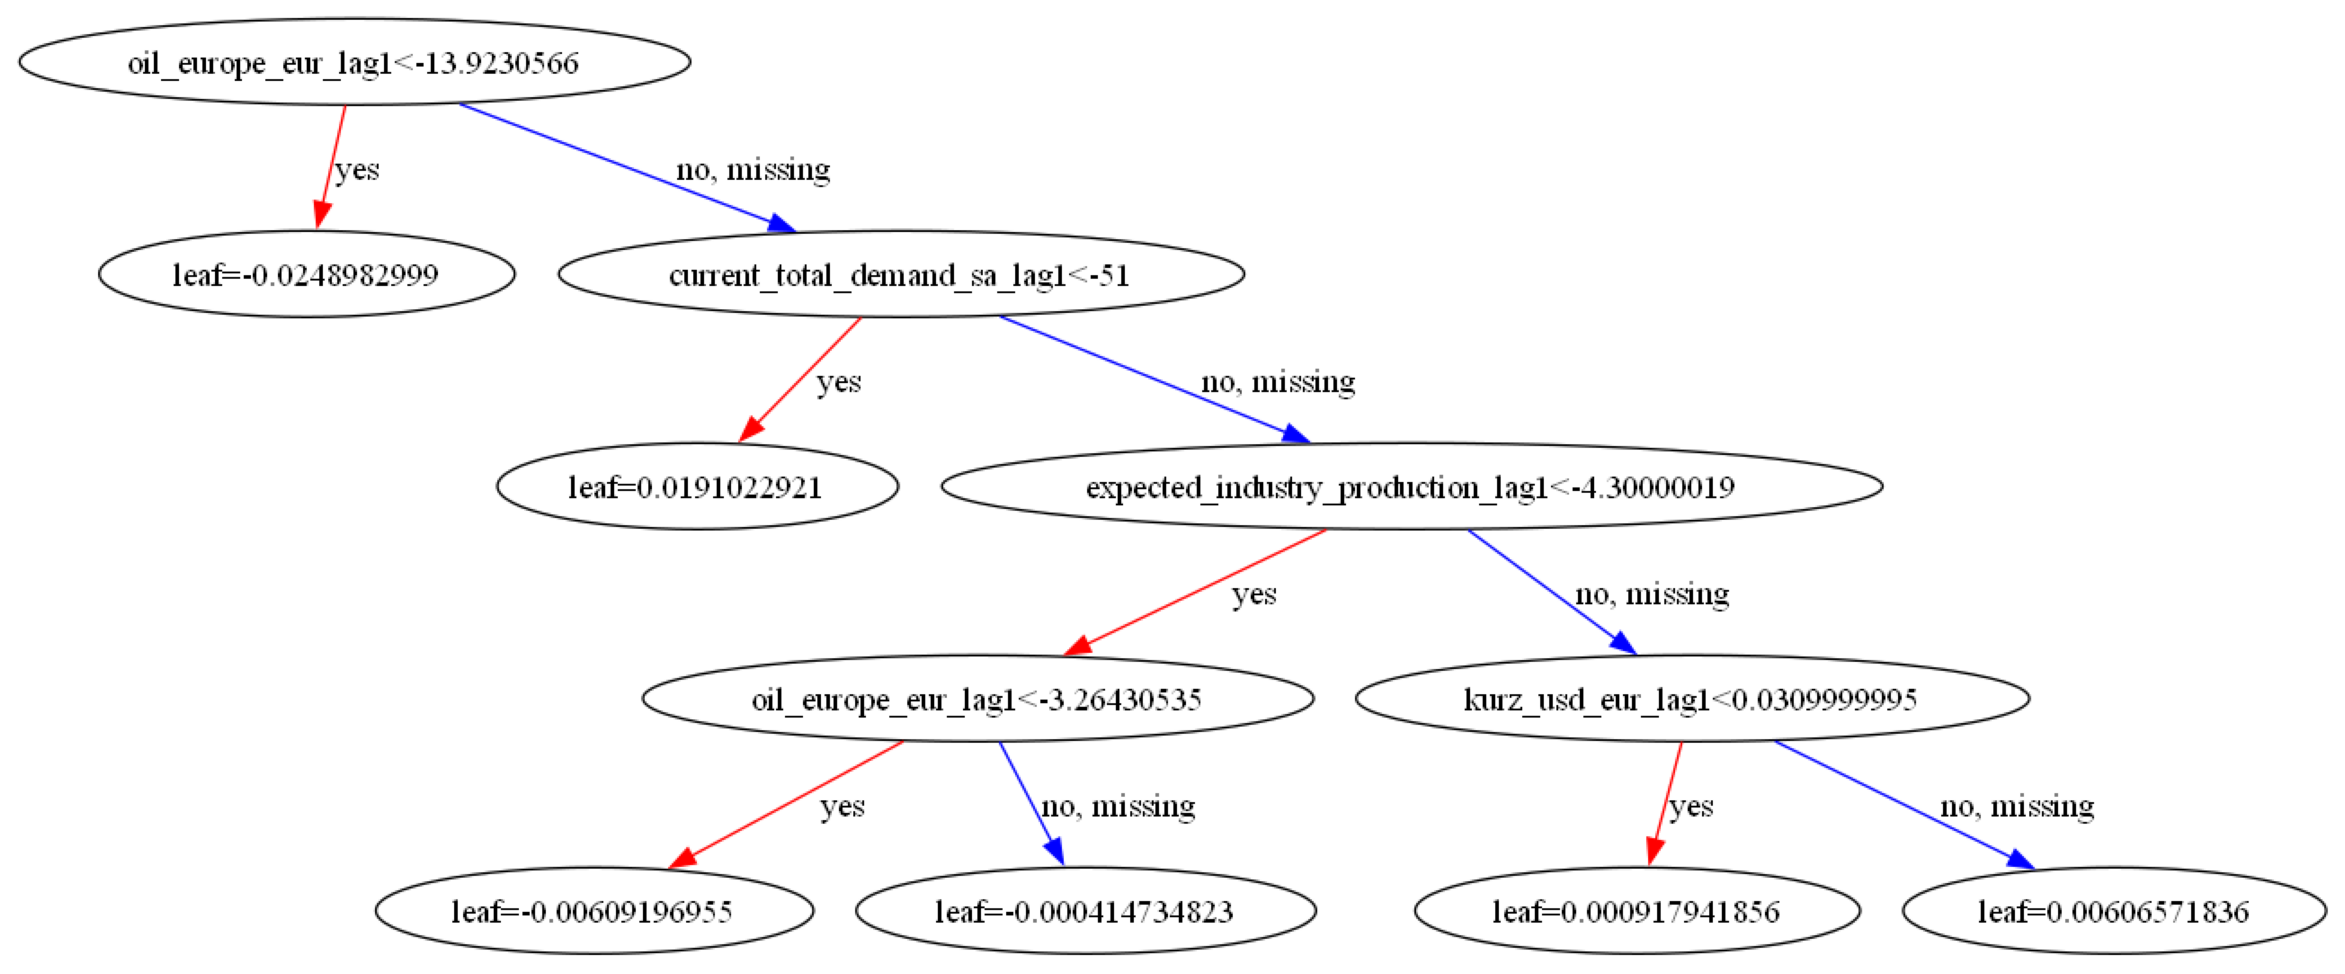

In [22]:
#graficke zobrazenie stromu
from xgboost import plot_tree
import matplotlib.pyplot as plt

plot_tree(xgb_model, num_trees=last_tree)
fig = plt.gcf()
fig.set_size_inches(30, 15)

In [23]:
#Pocet listov a vnutornych uzlov pre kazdy strom
tree_summary = trees_df.groupby("Tree").agg(
    n_nodes=("Node", "count"),
    n_leaves=("Feature", lambda x: (x == "Leaf").sum()),
).reset_index()

# pre binarny strom: n_splits = n_leaves - 1
tree_summary["n_splits"] = tree_summary["n_leaves"] - 1

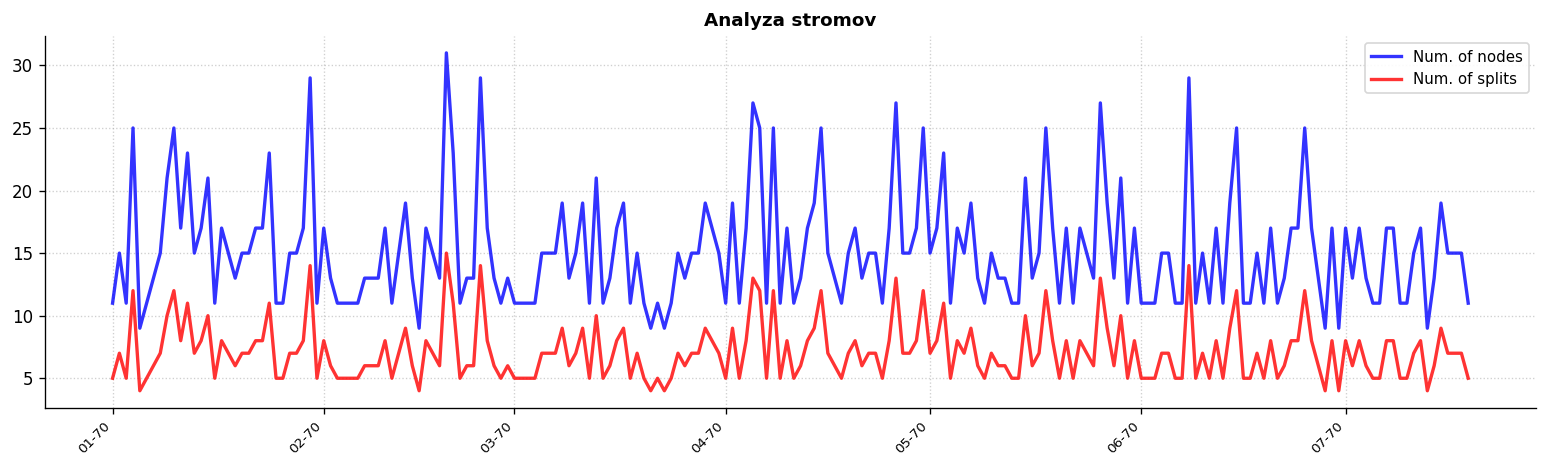

In [24]:
Y_axis = [tree_summary["n_nodes"],tree_summary["n_splits"]]
X_axis = [tree_summary["Tree"]] * len(Y_axis)
labels = ["Num. of nodes", "Num. of splits"] * len(Y_axis)
titles = ["Analyza stromov"]
colors = ["#0000FF", "#FF0000"] * len(Y_axis)
linestyles = ["-"] * len(Y_axis)
linewidths = [] * len(Y_axis)
alphas = [0.8] * len(Y_axis)
fig_size = [13,4]
num_rows = 1
num_cols = 1
curves_per_plot = 3

_ = forecast_plot(X_axis,Y_axis,titles, labels, colors, linestyles, linewidths, alphas,fig_size, num_rows, num_cols, curves_per_plot) #UPRAVIT OS X

In [25]:
#Zakladna statistika - kolko stromov ma 0, 1, 2+ deleni
split_distribution = tree_summary["n_splits"].value_counts().sort_index()
print("Rozdelenie poctu deleni naprieč stromami:")
print(split_distribution)

n_trivial = (tree_summary["n_splits"] == 0).sum()
n_single_split = (tree_summary["n_splits"] > 1).sum()
n_multi_split = (tree_summary["n_splits"] > 10).sum()

print(f"\nStromy bez delenia (len 1 list):       {n_trivial}")
print(f"Stromy s viac ako 1 delenim (3+ listy):    {n_single_split}")
print(f"Stromy s viac ako 10 delenim (21+ listy): {n_multi_split}")


Rozdelenie poctu deleni naprieč stromami:
n_splits
4      7
5     55
6     29
7     38
8     35
9     11
10     5
11     4
12     9
13     3
14     3
15     1
Name: count, dtype: int64[pyarrow]

Stromy bez delenia (len 1 list):       0
Stromy s viac ako 1 delenim (3+ listy):    200
Stromy s viac ako 10 delenim (21+ listy): 20


In [26]:
#ktore konkretne stromy maju viac ako 1 delenie
trees_with_multi_splits = tree_summary[tree_summary["n_splits"] > 1].sort_values(
    "n_splits", ascending=False
)
print("\nStromy s viac ako 1 delenim (zoradene podla poctu deleni):")
print(trees_with_multi_splits)


Stromy s viac ako 1 delenim (zoradene podla poctu deleni):
     Tree  n_nodes  n_leaves  n_splits
49     49       31        16        15
29     29       29        15        14
54     54       29        15        14
158   158       29        15        14
94     94       27        14        13
..    ...      ...       ...       ...
79     79        9         5         4
81     81        9         5         4
178   178        9         5         4
180   180        9         5         4
193   193        9         5         4

[200 rows x 4 columns]


In [27]:
# Priemerny pocet deleni cez cely ansambel - rychly diagnosticky ukazovatel
avg_splits = tree_summary["n_splits"].mean()
pct_trivial = (n_trivial / len(tree_summary)) * 100
print(f"\nPriemerny pocet deleni na strom: {avg_splits:.2f}")
print(f"Podiel trivialnych (nerozdelenych) stromov: {pct_trivial:.1f}%")


Priemerny pocet deleni na strom: 7.10
Podiel trivialnych (nerozdelenych) stromov: 0.0%
